# Inference Quick Start

This notebook shows how to run Migas-1.5 on **your own data** end-to-end:

1. **Fetch time series data** — download daily price history from Yahoo Finance.
2. **Prepare a text summary** — learn the two-part `FACTUAL SUMMARY` + `PREDICTIVE SIGNALS` format the model expects. A sample summary is provided so the notebook runs out of the box; an optional section shows how to auto-generate one with an LLM.
3. **Forecast** — compare Chronos-2 (text-free baseline) against Migas-1.5 (text-conditioned).
4. **Counterfactual exploration** — rewrite the predictive signals and watch the forecast shift, demonstrating the text-conditioned time series forecasting.

**Requirements:** Install the package from the repo root (`uv sync`). Section 3 (LLM summary generation) optionally requires an OpenAI or Anthropic API key.

**See also:** [Counterfactual Scenarios](migas-1.5-counterfactual-scenarios.ipynb) · [Batch Inference](migas-1.5-batch-inference.ipynb) · [Backtest and Metrics](migas-1.5-backtest-and-metrics.ipynb)

## User Configuration

**Edit the cell below before running anything else.** All parameters you are likely to
want to change are collected here — you should not need to touch anything else in the
notebook for a basic run.

| Parameter | What it controls | Typical values |
|-----------|-----------------|----------------|
| `TICKER` | Asset to forecast | Any Yahoo Finance symbol: `"AAPL"`, `"SPY"`, `"CL=F"` |
| `SEQ_LEN` | Days of price history fed to the model (context window) | shorter = clearer local trends |
| `PRED_LEN` | Number of trading days to forecast | `8` – `64` |
| `LLM_PROVIDER` | LLM used to auto-generate the text summary in Section 3 | `"anthropic"` (recommended) or `"openai"` |

**Also check:**
- **Section 2** — replace the pre-written `summary` with one that matches your asset and date window.
- **Section 5** — edit `bullish_predictive` / `bearish_predictive` to craft your own counterfactual narratives.

In [ ]:
import os

# ── USER CONFIGURATION — edit here, then run the notebook top-to-bottom ──────

TICKER       = "GLD"         # <-- CHANGE ME: any Yahoo Finance symbol (e.g. "AAPL", "SPY", "CL=F")
SEQ_LEN      = 64            # <-- CHANGE ME: context window in days
PRED_LEN     = 16            # <-- CHANGE ME: forecast horizon in days
LLM_PROVIDER = "anthropic"   # <-- CHANGE ME: "anthropic" (recommended) | "openai"
LLM_API_KEY  = os.getenv({"anthropic": "ANTHROPIC_API_KEY", "openai": "OPENAI_API_KEY"}[LLM_PROVIDER])

# ─────────────────────────────────────────────────────────────────────────────

In [50]:
import warnings

warnings.filterwarnings("ignore", message="IProgress not found")

import sys
from textwrap import dedent

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yfinance as yf

from migaseval import MigasPipeline
from migaseval.model.inference_utils import evaluate_chronos_quantiles

sys.path.insert(0, "..")
from scripts.counterfactual_utils import (composite_trend_score,
                                          extract_factual, extract_predictive,
                                          linear_slope, splice_summary)
from scripts.plotting_utils import (COLORS, _draw_forecast_region,
                                    apply_migas_style, plot_forecast_single)
from scripts.summary_utils import generate_summary

apply_migas_style()

device = "cuda" if torch.cuda.is_available() else "cpu"
pipeline = MigasPipeline.from_pretrained(
    "Synthefy/migas-1.5", device=device, text_embedder_device=device
)
print(f"Using device: {device}")

Initialized univariate models: chronos, timesfm (prophet on-demand)
Using device: cpu


## 1. Get Time Series Data

Below we fetch daily closing prices for Gold (GLD) from Yahoo Finance and keep the last `SEQ_LEN + PRED_LEN` trading days. The first `SEQ_LEN` days form the **context window** fed to the model; the remaining `PRED_LEN` days are held out as **ground truth** so we can measure forecast accuracy.

**Why GLD?** Gold responds cleanly to macro text (Fed policy, inflation, risk-off flows), making the text-conditioning effect easy to demonstrate.

You can swap `TICKER` for any Yahoo Finance symbol: stocks (`AAPL`, `MSFT`), ETFs (`SPY`, `GLD`), or futures (`CL=F` for crude oil).

In [51]:
raw = yf.download(TICKER, period="2y", auto_adjust=True, progress=False)["Close"]
raw = raw.dropna().squeeze()

# Fetch context + prediction window so we have ground truth for evaluation
full = raw.iloc[-(SEQ_LEN + PRED_LEN):].reset_index()
full.columns = ["t", "y_t"]
full["t"] = full["t"].dt.strftime("%Y-%m-%d")
full["text"] = ""

# Context window fed to the model
series = full.iloc[:SEQ_LEN].copy()

# Ground truth for the forecast horizon
gt_vals = full.iloc[SEQ_LEN:]["y_t"].values.astype(np.float32)

print(
    f"Context window : {len(series)} days  ({series['t'].iloc[0]} → {series['t'].iloc[-1]})"
)
print(
    f"Forecast window: {len(gt_vals)} days  ({full['t'].iloc[SEQ_LEN]} → {full['t'].iloc[-1]})"
)
print(f"Context price range : ${series['y_t'].min():.2f} – ${series['y_t'].max():.2f}")
series.tail()

Context window : 64 days  (2025-11-17 → 2026-02-19)
Forecast window: 16 days  (2026-02-20 → 2026-03-13)
Context price range : $371.65 – $495.90


,t,y_t,text
59,2026-02-12,451.390015,
60,2026-02-13,462.619995,
61,2026-02-17,448.200012,
62,2026-02-18,458.279999,
63,2026-02-19,459.559998,


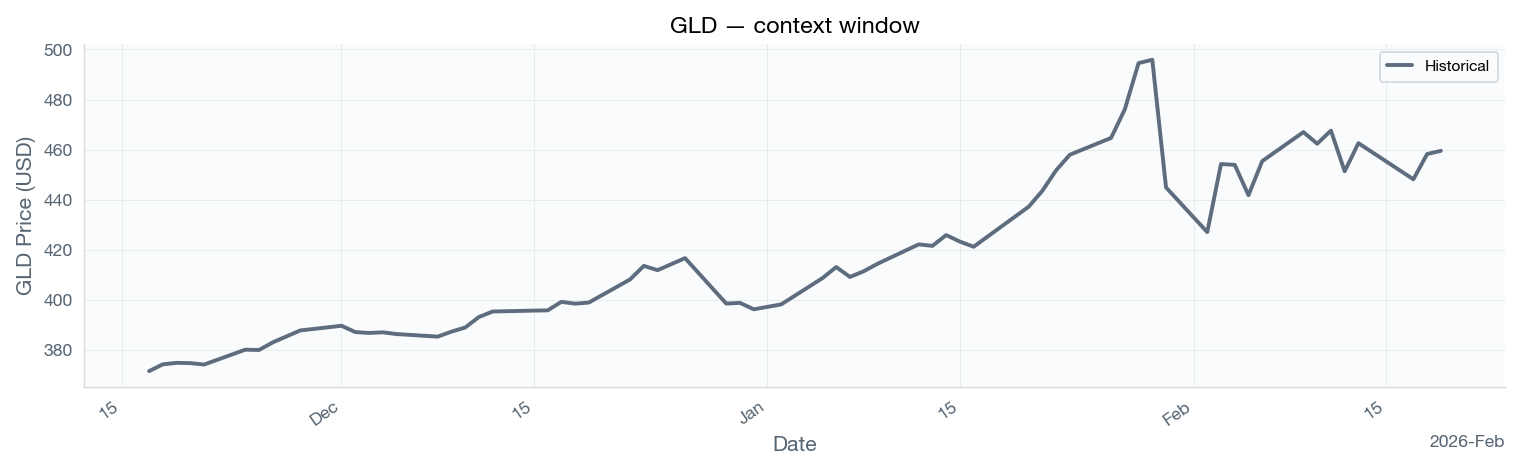

In [52]:
# Quick look at the context window before running the model
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(
    pd.to_datetime(series["t"].values),
    series["y_t"].values,
    color=COLORS["historical"],
    lw=2.0,
    solid_capstyle="round",
    label="Historical",
)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
for lbl in ax.get_xticklabels():
    lbl.set_rotation(35)
    lbl.set_ha("right")
ax.set_xlabel("Date", color="#566573")
ax.set_ylabel(f"{TICKER} Price (USD)", color="#566573")
ax.set_title(
    f"{TICKER} — context window"
)
ax.legend(fontsize=8, handlelength=1.6)
fig.tight_layout(pad=1.2)
plt.show()

## 2. Understanding the Summary Format

Migas-1.5 accepts **text summary** alongside the time series. The summary must follow a two-part structure:

| Section | Purpose |
|---------|---------|
| `FACTUAL SUMMARY` | What already happened — price action, key events, macro drivers |
| `PREDICTIVE SIGNALS` | Forward-looking interpretation — analyst outlook, catalysts, risks |

This is the format produced by Migas-1.5's internal `ContextSummarizer` (which calls an LLM over per-timestep news text). The model was trained to condition on this structure, so deviating significantly from it will reduce text impact.

Below is a sample GLD summary. **To generate a fresh one from real headlines, see Section 3.**

In [53]:
# Pre-computed sample summary — illustrates the required format.
# Replace the text below with a summary that matches your asset and date window,  # <-- CHANGE ME
# or let Section 3 generate one automatically with an LLM.
summary = """\
FACTUAL SUMMARY:
GLD has experienced a strong uptrend from November 2025 through January 2026, surging from ~372 to nearly 495 before a sharp pullback to ~445 on January 30, 2026, followed by consolidation in the 427-468 range through mid-February. Key drivers include billionaire hedge fund accumulation (Ken Griffin, Israel Englander), safe-haven demand amid geopolitical tensions and Trump administration policy uncertainty, weakening USD, and central bank buying. Technical support remains in place despite recent volatility, with institutional inflows offsetting prior outflows and multiple analysts citing bullish gold fundamentals for 2026.

PREDICTIVE SIGNALS:
GLD exhibits a bullish medium-term bias supported by ongoing safe-haven demand and institutional conviction, though the sharp January peak followed by consolidation suggests potential for further sideways to higher trading before the next directional move. Near-term momentum appears tentatively positive with recent recovery from lows, but elevated volatility and risk of a deeper pullback remain given the magnitude of the January advance and consolidation pattern, with key risks from USD strength or policy shifts.
"""

print(summary)

FACTUAL SUMMARY:
GLD has experienced a strong uptrend from November 2025 through January 2026, surging from ~372 to nearly 495 before a sharp pullback to ~445 on January 30, 2026, followed by consolidation in the 427-468 range through mid-February. Key drivers include billionaire hedge fund accumulation (Ken Griffin, Israel Englander), safe-haven demand amid geopolitical tensions and Trump administration policy uncertainty, weakening USD, and central bank buying. Technical support remains in place despite recent volatility, with institutional inflows offsetting prior outflows and multiple analysts citing bullish gold fundamentals for 2026.

PREDICTIVE SIGNALS:
GLD exhibits a bullish medium-term bias supported by ongoing safe-haven demand and institutional conviction, though the sharp January peak followed by consolidation suggests potential for further sideways to higher trading before the next directional move. Near-term momentum appears tentatively positive with recent recovery from 

## 3. (Optional) Generate a Summary with an LLM

A good summary requires **per-day news aligned to the context window**, not just a handful
of recent headlines. This section generates a `FACTUAL SUMMARY` + `PREDICTIVE SIGNALS` using
an LLM:

- **Anthropic (recommended)** — Claude uses its built-in web search tool to autonomously
  find news and market events for the exact date range, then summarizes them. No extra API
  key required beyond your Anthropic key.
- **OpenAI / vLLM** — generates a summary from price data only (no web search available).

**Required environment variables:**
- `ANTHROPIC_API_KEY` or `OPENAI_API_KEY` — required to call the LLM.

If no LLM key is found the section is skipped and the pre-computed summary is kept.

In [54]:
# LLM_PROVIDER is set in the User Configuration cell at the top of the notebook.
LLM_BASE_URL = os.getenv("VLLM_BASE_URL")   # None → use provider default
LLM_MODEL    = os.getenv("VLLM_MODEL")       # None → use provider default

In [55]:
if not LLM_API_KEY:
    print("Skipping LLM summary generation — no LLM API key found.")
    print("Using the pre-computed summary.")
else:
    summary, news_digest = generate_summary(
        TICKER, series, PRED_LEN,
        llm_provider=LLM_PROVIDER,
        llm_api_key=LLM_API_KEY,
        llm_base_url=LLM_BASE_URL,
        llm_model=LLM_MODEL,
        return_news=True,
    )
    if news_digest:
        print("\n" + "=" * 60)
        print("NEWS DIGEST (raw web search findings)")
        print("=" * 60)
        print(news_digest)

Using Claude web search for GLD (2025-11-17 → 2026-02-19) …

Generated summary:

FACTUAL SUMMARY:
GLD rose approximately 24% from ~$371 to ~$459 over the period, with the dominant move being an explosive parabolic rally from mid-January through January 28 that drove gold spot to an all-time high near $5,595/oz, fueled by a weakening dollar at four-year lows, the Fed's January rate hold, record global ETF inflows of 120 tonnes in January, sustained central bank buying (led by China's 15th consecutive monthly purchase), and COMEX tariff-arbitrage physical delivery dynamics. The rally abruptly reversed on January 29–30 when Kevin Warsh's nomination as the next Fed Chair triggered a hawkish policy repricing and a cascade of leveraged position unwinding, sending GLD from ~$495 back to ~$427 in roughly two sessions before stabilizing. February saw a partial recovery to the ~$448–$467 range as dip buyers returned, soft U.S. economic data re-raised the probability of 2026 Fed rate cuts, dollar

## 4. Forecast: Chronos-2 Baseline vs. Migas-1.5

We run two forecasts on the same numerical context:

- **Chronos-2** — Migas's own internal Chronos backbone, before text fusion.
- **Migas-1.5** — same Chronos base, fused with the text summary above.

Both share the **exact same normalization path and Chronos call** — so the gap
between the two lines is the pure text conditioning effect.

**If the pre-written summary doesn't match your actual data window**, text can
steer the forecast in the wrong direction (Migas MAPE > Chronos MAPE). Run
Section 3 to generate a window-aligned summary and close that gap.

In [56]:
context_vals = series["y_t"].values.astype(np.float32)
context_tensor = (
    torch.tensor(context_vals, dtype=torch.float32)
    .unsqueeze(0)
    .unsqueeze(-1)
    .to(device)  # (1, SEQ_LEN, 1)
)

# Migas-1.5 + its internal Chronos-2 baseline — same normalization path, one call
migas_fc, chronos_fc_raw = pipeline.predict_from_dataframe(
    series, pred_len=PRED_LEN, seq_len=SEQ_LEN,
    summaries=[summary], return_univariate=True,
)
chronos_fc = chronos_fc_raw

# Chronos-2 uncertainty band (10th / 90th percentile) — standalone call for shading only
chronos_q = evaluate_chronos_quantiles(
    context_tensor, PRED_LEN, device=device, chronos_device=device,
    quantile_levels=[0.1, 0.9],
)
chronos_lo = chronos_q["0.1"][0]
chronos_hi = chronos_q["0.9"][0]

print(
    f"Chronos-2 forecast : {chronos_fc.shape}  range [{chronos_fc.min():.0f}, {chronos_fc.max():.0f}]"
    f"  (80% band: [{chronos_lo.min():.0f}, {chronos_hi.max():.0f}])"
)
print(
    f"Migas-1.5 forecast : {migas_fc.shape}  range [{migas_fc.min():.0f}, {migas_fc.max():.0f}]"
)
print("Note: Chronos-2 line is Migas's own internal baseline. Gap = text conditioning effect.")

Chronos-2 forecast : (16,)  range [461, 500]  (80% band: [424, 564])
Migas-1.5 forecast : (16,)  range [461, 484]
Note: Chronos-2 line is Migas's own internal baseline. Gap = text conditioning effect.


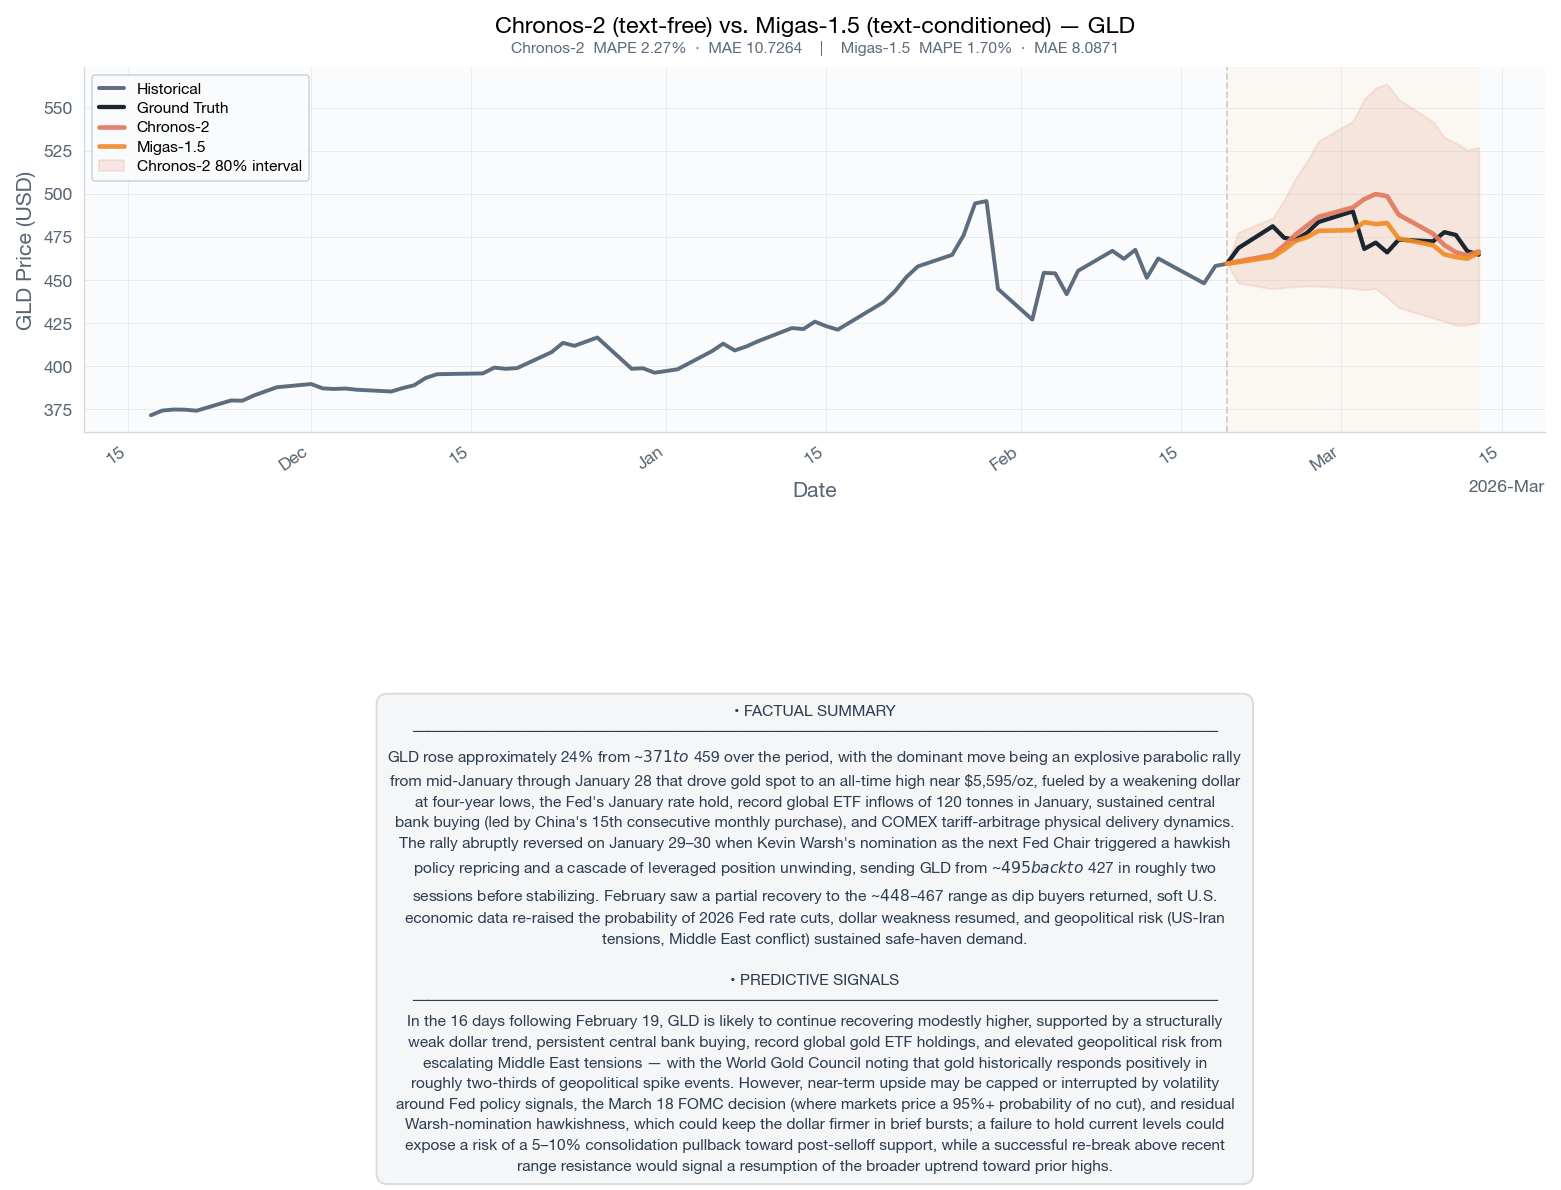

Chronos-2 slope  : -0.02701
Migas-1.5 slope  : -0.13894
Slope difference : -0.11192


In [57]:
t_ctx  = pd.to_datetime(full["t"].values[:SEQ_LEN])
t_pred = pd.to_datetime(list(full["t"].values[SEQ_LEN - 1:]))
last_val = float(context_vals[-1])

fig, ax = plot_forecast_single(
    context_vals,
    gt_vals,
    {"Chronos-2": chronos_fc, "Migas-1.5": migas_fc},
    SEQ_LEN,
    PRED_LEN,
    title=f"Chronos-2 (text-free) vs. Migas-1.5 (text-conditioned) — {TICKER}",
    figsize=(11, 4),
    show_metrics=True,
    text_summary=summary,
    timestamps=full["t"].values,
)
# Add Chronos-2 uncertainty band (10th–90th percentile)
ax.fill_between(
    t_pred,
    np.concatenate([[last_val], chronos_lo]),
    np.concatenate([[last_val], chronos_hi]),
    alpha=0.15,
    color=COLORS["Chronos-2"],
    label="Chronos-2 80% interval",
    zorder=2,
)
ax.legend(fontsize=8, handlelength=1.6, labelspacing=0.35, borderpad=0.45)
ax.set_ylabel(f"{TICKER} Price (USD)", color="#566573")
plt.show()

print(f"Chronos-2 slope  : {linear_slope(chronos_fc):+.5f}")
print(f"Migas-1.5 slope  : {linear_slope(migas_fc):+.5f}")
print(f"Slope difference : {linear_slope(migas_fc) - linear_slope(chronos_fc):+.5f}")

## 5. Counterfactual — Rewrite the Narrative

Here is the core idea behind Migas-1.5: **the numerical input is identical across all
runs below — only the text changes.**

We keep the **factual section** unchanged (what already happened doesn't change) and
replace only the **predictive signals** with a bullish or bearish outlook.
If the model truly integrates text with time series, the forecast should shift
in the direction of the new narrative.

In [58]:
print("Factual section (unchanged across all scenarios):\n")
print(extract_factual(summary))
print("\nOriginal predictive section:\n")
print(extract_predictive(summary))

Factual section (unchanged across all scenarios):

FACTUAL SUMMARY:
GLD rose approximately 24% from ~$371 to ~$459 over the period, with the dominant move being an explosive parabolic rally from mid-January through January 28 that drove gold spot to an all-time high near $5,595/oz, fueled by a weakening dollar at four-year lows, the Fed's January rate hold, record global ETF inflows of 120 tonnes in January, sustained central bank buying (led by China's 15th consecutive monthly purchase), and COMEX tariff-arbitrage physical delivery dynamics. The rally abruptly reversed on January 29–30 when Kevin Warsh's nomination as the next Fed Chair triggered a hawkish policy repricing and a cascade of leveraged position unwinding, sending GLD from ~$495 back to ~$427 in roughly two sessions before stabilizing. February saw a partial recovery to the ~$448–$467 range as dip buyers returned, soft U.S. economic data re-raised the probability of 2026 Fed rate cuts, dollar weakness resumed, and geopoli

In [59]:
bullish_predictive = dedent("""  # <-- CHANGE ME: rewrite with your own bullish narrative
    PREDICTIVE SIGNALS:
    Gold is entering an extreme upside regime: the Fed has unexpectedly pivoted to an
    aggressive rate-cut path following a sharp deterioration in labor-market data, real
    yields are collapsing, and the dollar is in free fall. Central banks are accelerating
    reserve diversification away from Treasuries, ETF inflows are surging to multi-year
    highs, and retail safe-haven demand is spiking. The path of least resistance is sharply
    higher, with a rapid continuation move and further record highs far more likely than
    any meaningful pullback over the forecast window.
""").strip()

bearish_predictive = dedent("""  # <-- CHANGE ME: rewrite with your own bearish narrative
    PREDICTIVE SIGNALS:
    Gold is entering an extreme downside regime after a sudden hawkish pivot: the Fed has
    signaled rates will stay higher for longer following a stronger-than-expected CPI print,
    real yields are surging to multi-year highs, and the dollar is strengthening sharply.
    ETF outflows have accelerated, speculative long positions are being unwound, and risk
    appetite has improved dramatically, reducing safe-haven demand. The highest-probability
    path over the forecast window is a rapid, sustained decline as rising yields crush the
    non-yielding metal with little prospect of near-term recovery.
""").strip()

bullish_summary = splice_summary(summary, bullish_predictive)
bearish_summary = splice_summary(summary, bearish_predictive)

In [60]:
bullish_fc = pipeline.predict_from_dataframe(
    series, pred_len=PRED_LEN, seq_len=SEQ_LEN, summaries=[bullish_summary]
)
bearish_fc = pipeline.predict_from_dataframe(
    series, pred_len=PRED_LEN, seq_len=SEQ_LEN, summaries=[bearish_summary]
)

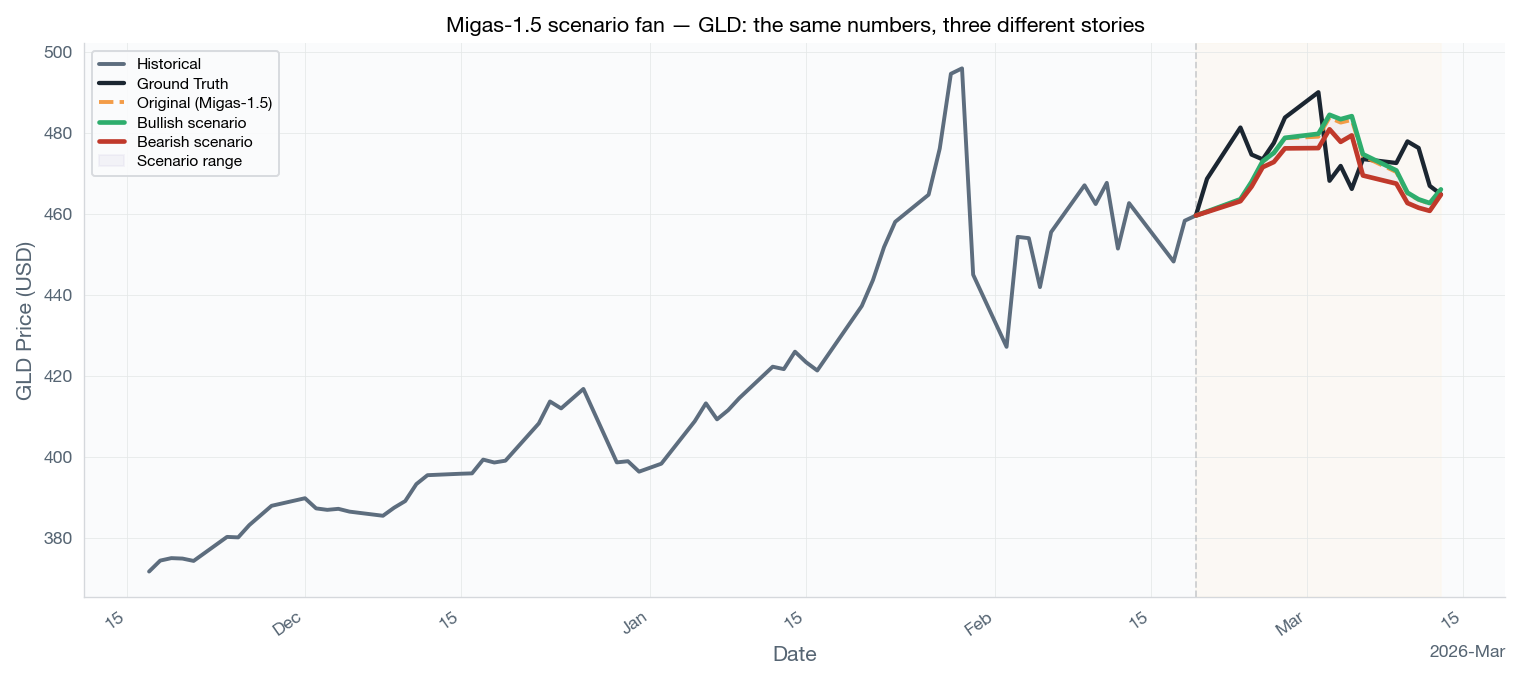

In [61]:
BULLISH_COLOR = "#2EAD6D"
BEARISH_COLOR = "#C0392B"

t_ctx  = pd.to_datetime(full["t"].values[:SEQ_LEN])
t_pred = pd.to_datetime(list(full["t"].values[SEQ_LEN - 1:]))
last_val = float(context_vals[-1])

fig, ax = plt.subplots(figsize=(11, 5))
_draw_forecast_region(ax, SEQ_LEN, PRED_LEN, boundary=t_pred[0], boundary_end=t_pred[-1])

ax.plot(
    t_ctx,
    context_vals,
    color=COLORS["historical"],
    lw=2.0,
    label="Historical",
    solid_capstyle="round",
)
ax.plot(
    t_pred,
    np.concatenate([[last_val], gt_vals]),
    color=COLORS["ground_truth"],
    lw=2.2,
    label="Ground Truth",
    solid_capstyle="round",
)
ax.plot(
    t_pred,
    np.concatenate([[last_val], migas_fc]),
    color=COLORS["Migas-1.5"],
    lw=2.0,
    ls="--",
    alpha=0.85,
    label="Original (Migas-1.5)",
    solid_capstyle="round",
)
ax.plot(
    t_pred,
    np.concatenate([[last_val], bullish_fc]),
    color=BULLISH_COLOR,
    lw=2.4,
    label="Bullish scenario",
    solid_capstyle="round",
)
ax.plot(
    t_pred,
    np.concatenate([[last_val], bearish_fc]),
    color=BEARISH_COLOR,
    lw=2.4,
    label="Bearish scenario",
    solid_capstyle="round",
)
ax.fill_between(
    t_pred,
    np.concatenate([[last_val], bearish_fc]),
    np.concatenate([[last_val], bullish_fc]),
    alpha=0.08,
    color="#9B8EC4",
    label="Scenario range",
)

ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
for lbl in ax.get_xticklabels():
    lbl.set_rotation(35)
    lbl.set_ha("right")
ax.set_xlabel("Date", color="#566573")
ax.set_ylabel(f"{TICKER} Price (USD)", color="#566573")
ax.set_title(
    f"Migas-1.5 scenario fan — {TICKER}: the same numbers, three different stories",
    fontsize=11,
    fontweight=600,
)
ax.legend(fontsize=8, handlelength=1.6, labelspacing=0.35, borderpad=0.45)
fig.tight_layout(pad=1.2)
plt.show()

In [62]:
orig_slope = linear_slope(migas_fc)
bull_slope = linear_slope(bullish_fc)
bear_slope = linear_slope(bearish_fc)

rows = [
    {
        "Scenario": "Chronos-2 (no text)",
        "Slope": f"{linear_slope(chronos_fc):+.5f}",
        "Slope shift vs original": "—",
        "Trend score (↑)": f"{composite_trend_score(chronos_fc, 'up', context_vals):+.3f}",
    },
    {
        "Scenario": "Migas-1.5 original",
        "Slope": f"{orig_slope:+.5f}",
        "Slope shift vs original": "—",
        "Trend score (↑)": f"{composite_trend_score(migas_fc, 'up', context_vals):+.3f}",
    },
    {
        "Scenario": "Bullish",
        "Slope": f"{bull_slope:+.5f}",
        "Slope shift vs original": f"{bull_slope - orig_slope:+.5f}",
        "Trend score (↑)": f"{composite_trend_score(bullish_fc, 'up', context_vals):+.3f}",
    },
    {
        "Scenario": "Bearish",
        "Slope": f"{bear_slope:+.5f}",
        "Slope shift vs original": f"{bear_slope - orig_slope:+.5f}",
        "Trend score (↑)": f"{composite_trend_score(bearish_fc, 'up', context_vals):+.3f}",
    },
]
print(pd.DataFrame(rows).to_string(index=False))

           Scenario    Slope Slope shift vs original Trend score (↑)
Chronos-2 (no text) -0.02701                       —          -0.043
 Migas-1.5 original -0.13894                       —          -0.142
            Bullish -0.12651                +0.01242          -0.139
            Bearish -0.24839                -0.10945          -0.167


The table confirms what the plot shows: the bullish narrative steers the slope positive,
the bearish narrative pulls it negative — all with the same 64 days of price history.
Compare the Chronos-2 row (no text) with Migas-1.5 to see the baseline text effect.

## What's next

- **Try your own asset** — change `TICKER` and `SEQ_LEN` in the **User Configuration** cell at the top.
- **Generate a fresh summary** — set your API key and re-run Section 3 for a summary
  grounded in real recent headlines.
- **Batch evaluation** — see [Backtest and Metrics](migas-1.5-backtest-and-metrics.ipynb)
  for rolling-window evaluation with ground truth.